# Consulta de reseñas

En este notebook, se ejecuta paso a paso todo lo necesario para realizar la consulta del conteo de reseñas de cada tipo (Buena, Mala, Informativa) para cada alojamiento, imprimiendo el top 5.

Para esta consulta, es necesario aplicar un modelo de PLN. Nosotros usaremos uno muy básico de análisis de sentimiento, que clasifica textos según palabras clave, asociando sentimientos buenos o malos a las palabras. Este modelo es **VADER**.

## Importación de librerías

In [1]:
import sys
import pathlib

notebook_dir = pathlib.Path.cwd()
project_root = notebook_dir.parent.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print(f"Directorio raíz añadido al path: {project_root}")

Directorio raíz añadido al path: /home/dani/Universidad/3o/2o-cuatri/SDPDII/Practicas/proy_SSDD_II


In [2]:
from src.kafka.consumer_kafka import create_kafka_stream_df, consumer_kafka_avro

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, pandas_udf, window
from pyspark.sql.types import StringType
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

## Verificar cola de Apache Kafka

El siguiente paso es comprobar que están los datos esperando en la cola de Apache Kafka. Para ello, vamos a usar la función implementada de consumidor, que imprime por pantalla los datos recibidos.

In [3]:
consumer_kafka_avro(
    topic='airbnb_reviews_gold', 
    idle_timeout_seconds=10, 
    log_to_file=False
)

2026-05-06 17:41:18,494 [INFO] Escritura de logs en archivo desactivada.
2026-05-06 17:41:18,495 [INFO] --- INICIANDO MONITOR PARA: airbnb_reviews_gold ---
2026-05-06 17:41:18,546 [INFO] Configurando deserializador AVRO para airbnb_reviews_gold
2026-05-06 17:41:18,635 [INFO] Esquema detectado: airbnb_reviews_gold tiene 9 columnas.
2026-05-06 17:41:18,769 [INFO] Topic airbnb_reviews_gold: 5000 mensajes procesados.
2026-05-06 17:41:18,895 [INFO] Topic airbnb_reviews_gold: 10000 mensajes procesados.
2026-05-06 17:41:19,017 [INFO] Topic airbnb_reviews_gold: 15000 mensajes procesados.
2026-05-06 17:41:19,145 [INFO] Topic airbnb_reviews_gold: 20000 mensajes procesados.
2026-05-06 17:41:19,268 [INFO] Topic airbnb_reviews_gold: 25000 mensajes procesados.
2026-05-06 17:41:19,391 [INFO] Topic airbnb_reviews_gold: 30000 mensajes procesados.
2026-05-06 17:41:19,514 [INFO] Topic airbnb_reviews_gold: 35000 mensajes procesados.
2026-05-06 17:41:19,637 [INFO] Topic airbnb_reviews_gold: 40000 mensajes 

## Consulta con Spark Streaming

Primero, tenemos que crear la sesión de Spark. Es importante destacar el paquete de Spark para Apache Kafka y Avro.

In [4]:
spark = SparkSession.builder \
    .appName("Notebook_Borrador_Reviews") \
    .config("spark.jars.packages", "org.apache.spark:spark-sql-kafka-0-10_2.13:4.1.1,org.apache.spark:spark-avro_2.13:4.1.1") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark Session iniciada con éxito.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/06 17:41:37 WARN Utils: Your hostname, dani, resolves to a loopback address: 127.0.1.1; using 192.168.1.86 instead (on interface wlp62s0)
26/05/06 17:41:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/dani/Universidad/3o/2o-cuatri/SDPDII/Practicas/proy_SSDD_II/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/dani/.ivy2.5.2/cache
The jars for the packages stored in: /home/dani/.ivy2.5.2/jars
org.apache.spark#spark-sql-kafka-0-10_2.13 added as a dependency
org.apache.spark#spark-avro_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-2b17cd50-6221-480c-931b-eb15111199c3;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.13;4.1.1 in central
	found org.apache.spark#spark-token-provider-ka

Spark Session iniciada con éxito.


Definimos la función a usar con PLN (**VADER**). Para esta función, usaremos la librería de NLTK (vista en clase).

In [5]:
# --------- NLP MODEL DEFINITION ---------
@pandas_udf(StringType())
def classify_review(comentarios: pd.Series) -> pd.Series:
    nltk.download('vader_lexicon', quiet=True)
    
    # Initialize VADER analyzer
    sia = SentimentIntensityAnalyzer()
    
    def evaluate_feeling(texto):
        if not texto or pd.isna(texto):
            return "informativa"
        
        # Get VADER polarity scores
        scores = sia.polarity_scores(str(texto))
        
        # Extract compound score
        compound = scores['compound']
        
        # Apply thresholds
        if compound > 0.15: 
            return "buena"
        elif compound < -0.15: 
            return "mala"
        else: 
            return "informativa"
            
    return comentarios.apply(evaluate_feeling)

Antes de realizar el flujo de verdad, vamos a comprobar el funcionamiento del modelo PLN usado con unas reviews de prueba sencillas.

In [6]:
# --------- VADER MODEL UNIT TEST ---------

# Define extreme test cases
datos_prueba = [
    ("1", "The apartment is amazing, wonderful views and very clean. We loved it!"),  # Good
    ("2", "Horrible experience. It was noisy, dirty and the host didn't reply."), # Bad
    ("3", "The apartment has a microwave, two single beds and is on the 3rd floor."), # Informative
    ("4", None)
]

# Create temporary static Spark DataFrame
df_test = spark.createDataFrame(datos_prueba, ["id_falso", "comments"])

print("Evaluando textos de prueba controlados...")

# Apply UDF
df_resultado_test = df_test.withColumn("clasificacion_vader", classify_review(col("comments")))

# Show results
df_resultado_test.select("comments", "clasificacion_vader").show(truncate=False)

Evaluando textos de prueba controlados...


+-----------------------------------------------------------------------+-------------------+
|comments                                                               |clasificacion_vader|
+-----------------------------------------------------------------------+-------------------+
|The apartment is amazing, wonderful views and very clean. We loved it! |buena              |
|Horrible experience. It was noisy, dirty and the host didn't reply.    |mala               |
|The apartment has a microwave, two single beds and is on the 3rd floor.|informativa        |
|NULL                                                                   |informativa        |
+-----------------------------------------------------------------------+-------------------+



[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     UNEXPECTED_EOF_WHILE_READING] EOF occurred in
[nltk_data]     violation of protocol (_ssl.c:1000)>


Comenzamos el flujo de Spark Streaming. Primero leemos los datos de la cola, aplicamos la clasificación de reviews y el Event Time. Por último agrupamos por tiempo de evento, anuncio (`listing_id`) y el tipo de review (obtenido en el paso anterior).

In [7]:
# Read stream using imported function
df_reviews_crudo = create_kafka_stream_df(spark, "airbnb_reviews_gold")

# Apply classification and date cast
df_procesado = df_reviews_crudo \
    .withColumn("tipo_review", classify_review(col("comments"))) \
    .withColumn("event_timestamp", col("date").cast("timestamp"))

# Window and count
df_agrupado = df_procesado \
    .withWatermark("event_timestamp", "7 days") \
    .groupBy(
        window(col("event_timestamp"), "365 days"),
        col("tipo_review")
    ).count()

# Sort chronologically
df_final = df_agrupado.orderBy(col("window.start").desc(), col("tipo_review"))

Iniciamos el flujo streaming.

In [8]:
# Inicializate stream
query_reviews = df_final.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("tabla_resultados_reviews") \
    .start()

26/05/06 17:42:56 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-f9890098-59e1-4c81-b7be-d1f20f0a7983. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/05/06 17:42:56 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [87]:
# Query
spark.sql("SELECT * FROM tabla_resultados_reviews").show(truncate=False)

+------------------------------------------+-----------+-----+
|window                                    |tipo_review|count|
+------------------------------------------+-----------+-----+
|{2024-12-18 01:00:00, 2025-12-18 01:00:00}|buena      |54586|
|{2024-12-18 01:00:00, 2025-12-18 01:00:00}|informativa|33214|
|{2024-12-18 01:00:00, 2025-12-18 01:00:00}|mala       |13164|
|{2023-12-19 01:00:00, 2024-12-18 01:00:00}|buena      |61290|
|{2023-12-19 01:00:00, 2024-12-18 01:00:00}|informativa|34270|
|{2023-12-19 01:00:00, 2024-12-18 01:00:00}|mala       |13794|
|{2022-12-19 01:00:00, 2023-12-19 01:00:00}|buena      |50280|
|{2022-12-19 01:00:00, 2023-12-19 01:00:00}|informativa|24925|
|{2022-12-19 01:00:00, 2023-12-19 01:00:00}|mala       |10287|
|{2021-12-19 01:00:00, 2022-12-19 01:00:00}|buena      |39111|
|{2021-12-19 01:00:00, 2022-12-19 01:00:00}|informativa|15833|
|{2021-12-19 01:00:00, 2022-12-19 01:00:00}|mala       |5751 |
|{2020-12-19 01:00:00, 2021-12-19 01:00:00}|buena      

/tmp/ipykernel_95406/2220310844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_reviews, x='tipo_review', y='count', palette=colores)


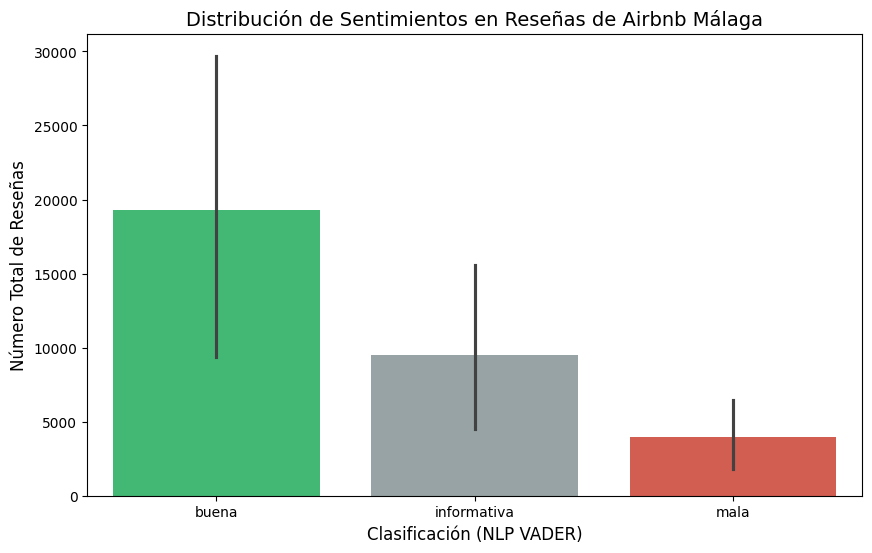

26/05/06 20:02:39 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1 (localhost/127.0.0.1:9092) could not be established. Node may not be available.
26/05/06 20:02:40 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1 (localhost/127.0.0.1:9092) could not be established. Node may not be available.
26/05/06 20:02:41 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1 (localhost/127.0.0.1:9092) could not be established. Node may not be available.
26/05/06 20:02:42 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1 (localhost/127.0.0.1:9092) could not be established. Node may not be available.
26/05/06 20:02:43 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1 (localhost/127.0.0.1:9092) could not be established. Node may not be available.
26/05/06 20:02:44 WARN NetworkClient: [AdminClient clientId=adminclient-1] Connection to node 1 (localhost/127.0.0.1:909

In [88]:
df_reviews = spark.sql("SELECT tipo_review, count FROM tabla_resultados_reviews").toPandas()

colores = {'buena': '#2ecc71', 'informativa': '#95a5a6', 'mala': '#e74c3c'}

plt.figure(figsize=(10, 6))
sns.barplot(data=df_reviews, x='tipo_review', y='count', palette=colores)

plt.title('Distribución de Sentimientos en Reseñas de Airbnb Málaga', fontsize=14)
plt.xlabel('Clasificación (NLP VADER)', fontsize=12)
plt.ylabel('Número Total de Reseñas', fontsize=12)
plt.show()